# How the CP and HD curves change with the white-noise level

The baseline astrometric noise is $\sigma = 1$ mas. This notebook plugs in $\sigma$ = 1, 0.1, 0.01 and 0.001 mas and recomputes the CP and HD SNR curves for each one.

The noise enters through the noise power $P_n = 2\sigma^2\Delta t$, the same expression as in `main.py`. For each $\sigma$, the covariance matrices are built with that $P_n$ and the GW amplitude $A_{gw}$ is swept, so $\sigma$ is literally plugged into the calculation.

The results are shown two ways:

1. **Your usual plot**, with $x = P_{gw}(f_l)/P_n(f_l)$, one panel per noise level.
2. **The same curves against $A_{gw}$**, which does not depend on the noise, so the shift is visible.

Change `SIGMAS_MAS` or `N_STARS_NB` in the next cell to try other values.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

sys.path.insert(0, os.getcwd())
import main as M

# main.py selects the Agg backend for Slurm; switch back to inline plots here.
%matplotlib inline

# ---------------- settings ----------------
SIGMAS_MAS = [1.0, 0.1, 0.01, 0.001]   # noise levels to compare
N_STARS_NB = 40                         # HD uses a dense pair matrix, so keep N <= ~60
FOV        = M.FIELD_SIZE_DEG
# ------------------------------------------

c, F = M.POL_FACTOR, M.gamma_scale_factor()
CP_COL, HD_COL = "#2a78d6", "#eb6834"
SIG_COL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
SIG_LS  = ["-", "--", "-.", ":"]
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2,
    "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 9, "legend.frameon": False,
})
print(f"N = {N_STARS_NB}, FoV = {FOV:g} deg, POL_FACTOR = {c}, A_gw (NANOGrav) = {M.A_gw:g}")

N = 40, FoV = 10 deg, POL_FACTOR = 2.0, A_gw (NANOGrav) = 1e-15


## Building the covariances with a given noise level

These are the same covariances as in `main.py` and `hd_full_matrix_snr.py`, written in physical units so that $P_n$ (and so $\sigma$) appears explicitly.

- **CP:** $\tilde C_{ab} = cFP_{gw}\Gamma_{ab} + P_n\delta_{ab}$, $\;C_{ab} = f_l^{14/3}|\tilde C_{ab}|^2/F^2$, $\;\rho^2 = P_{gw}^2 f_l^{14/3}\sum_{ab}(C^{-1})_{ab}$
- **HD:** $P_{ab} = cFP_{gw}\Gamma_{ab}$, $\;P_{aa} = P_n + cFP_{gw}\gamma_0$, $\;C_{ab,cd} = (P_{ac}P_{bd}+P_{ad}P_{bc})/(F_{ab}F_{cd})$, $\;\rho^2 = 2P_{gw}^2\sum(C^{-1})$

In [2]:
def noise_power(sigma_mas):
    # P_n = 2 sigma^2 dt  (sigma in mas, converted to radians)
    sigma_rad = (sigma_mas * u.mas).to(u.rad).value
    return 2.0 * sigma_rad**2 * M.dt_seconds

def gw_power(A):
    # P_gw(f_l) for amplitude A, same expression as main.py
    return (A**2 / (12 * np.pi**2)) * (M.f_l / M.f_yr)**(-4/3) / M.f_l

# Star field and Gamma matrix
stars = M.build_star_positions(None, N_STARS_NB, FOV, M.RANDOM_SEED)
theta = M.pairwise_theta(stars)
ell_min, ell_max = M.compute_ell_limits(theta, FOV)
gam = M.gamma_parallel_matrix(theta, ell_min, ell_max, batch_size=20000)
g0 = M.cp_single_star_gamma(ell_min, ell_max)
Gam = M.cp_gamma_matrix(gam, g0)                  # Gamma with Gamma(0) on the diagonal
a_idx, b_idx = np.triu_indices(N_STARS_NB, 1)
F_ab = F * Gam[a_idx, b_idx]

def rho_cp(Pgw, Pn):
    Ct = c * F * Pgw * Gam + Pn * np.eye(N_STARS_NB)
    C = M.f_l**(14/3) * Ct**2 / F**2
    s = C.max()                                    # rescale so the solve is well scaled
    return np.sqrt(Pgw**2 * M.f_l**(14/3) / s * np.linalg.solve(C / s, np.ones(N_STARS_NB)).sum())

def rho_hd(Pgw, Pn):
    P = c * F * Pgw * Gam.copy()
    np.fill_diagonal(P, Pn + c * F * Pgw * g0)
    C = (P[a_idx][:, a_idx] * P[b_idx][:, b_idx] + P[a_idx][:, b_idx] * P[b_idx][:, a_idx]) / np.outer(F_ab, F_ab)
    s = C.max()
    return np.sqrt(2 * Pgw**2 / s * np.linalg.solve(C / s, np.ones(len(a_idx))).sum())

# For each noise level, sweep the GW amplitude over the range that covers the
# same x-range as main.py (P_gw/P_n from 1e-13 to 1e2). Using the same x points
# for every noise level lets the curves be compared point by point.
ratio_grid = np.logspace(-13, 2, 121)
curves = {}
for sig in SIGMAS_MAS:
    Pn = noise_power(sig)
    Pgw = ratio_grid * Pn                          # GW power at each x value
    A = np.sqrt(Pgw / gw_power(1.0))               # amplitude that gives that power
    cp = np.array([rho_cp(x, Pn) for x in Pgw])
    hd = np.array([rho_hd(x, Pn) for x in Pgw])
    curves[sig] = dict(A=A, ratio=ratio_grid, cp=cp, hd=hd, Pn=Pn,
                       ratio_phys=gw_power(M.A_gw) / Pn)
    print(f"sigma = {sig:6g} mas:  P_n = {Pn:.2e},  physical P_gw/P_n = {curves[sig]['ratio_phys']:.1e}")

sigma =      1 mas:  P_n = 8.46e-14,  physical P_gw/P_n = 5.9e-11


sigma =    0.1 mas:  P_n = 8.46e-16,  physical P_gw/P_n = 5.9e-09


sigma =   0.01 mas:  P_n = 8.46e-18,  physical P_gw/P_n = 5.9e-07


sigma =  0.001 mas:  P_n = 8.46e-20,  physical P_gw/P_n = 5.9e-05


## 1. Your usual plot, for each noise level

Same axes as the `main.py` and `hd_full_matrix_snr.py` plots. The dashed line is the physical value of $P_{gw}(f_l)/P_n$ for that noise level.

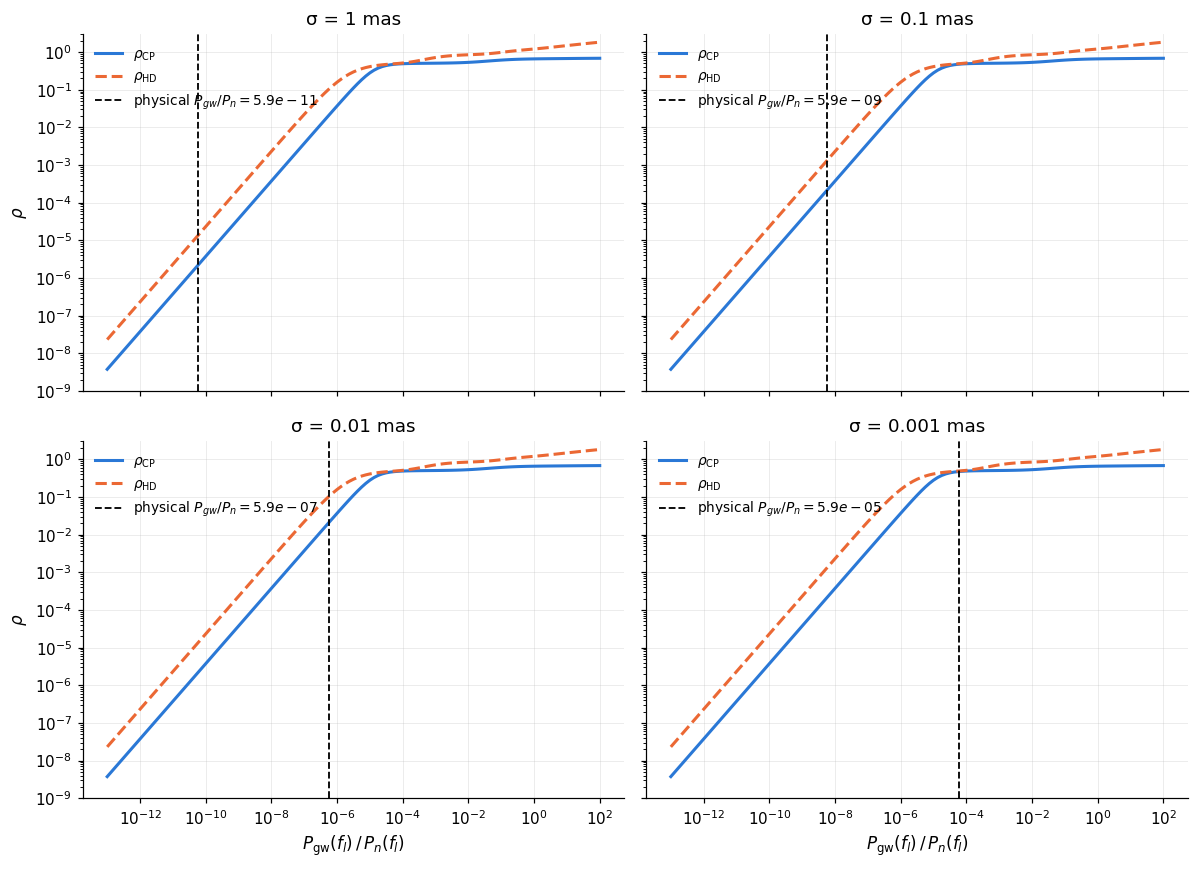

sigma = 0.1 mas vs 1 mas, same x value: largest relative difference CP 2e-12, HD 5e-05
sigma = 0.01 mas vs 1 mas, same x value: largest relative difference CP 9e-13, HD 8e-05
sigma = 0.001 mas vs 1 mas, same x value: largest relative difference CP 5e-13, HD 2e-05


In [3]:
fig, axs = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, sig in zip(axs.flat, SIGMAS_MAS):
    d = curves[sig]
    ax.loglog(d["ratio"], d["cp"], color=CP_COL, ls="-", label=r"$\rho_{\rm CP}$")
    ax.loglog(d["ratio"], d["hd"], color=HD_COL, ls="--", label=r"$\rho_{\rm HD}$")
    ax.axvline(d["ratio_phys"], color="k", lw=1.2, ls="--",
               label=rf"physical $P_{{gw}}/P_n = {d['ratio_phys']:.1e}$")
    ax.set_title(f"σ = {sig:g} mas")
    ax.set_ylim(1e-9, 3)
    ax.legend(loc="upper left")
for ax in axs[1]:
    ax.set_xlabel(r"$P_{\rm gw}(f_l)\,/\,P_n(f_l)$")
for ax in axs[:, 0]:
    ax.set_ylabel(r"$\rho$")
plt.tight_layout(); plt.show()

# How different are the curves between noise levels at the same x value?
ref = curves[SIGMAS_MAS[0]]
for sig in SIGMAS_MAS[1:]:
    d = curves[sig]
    print(f"sigma = {sig:g} mas vs 1 mas, same x value: largest relative difference "
          f"CP {np.max(np.abs(d['cp']/ref['cp']-1)):.0e}, HD {np.max(np.abs(d['hd']/ref['hd']-1)):.0e}")

**What this shows.** The four panels have the same CP and HD curves. Only the dashed line moves, 100 times further right for every factor of 10 less noise. With this x-axis, $P_n$ divides out of every term, so the curve shape does not depend on the noise. The printed differences between noise levels are at the level of numerical round-off.

## 2. The same curves against GW amplitude

$A_{gw}$ does not depend on the noise, so on this axis the curves move. The dotted line is the NANOGrav amplitude $A_{gw}=10^{-15}$ used in `main.py`.

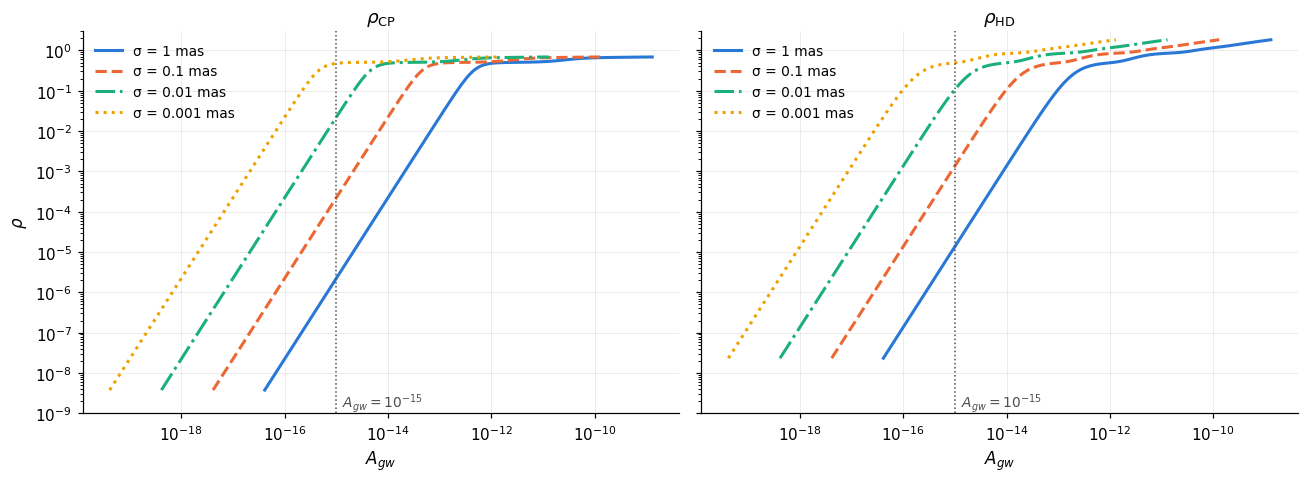

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for i, sig in enumerate(SIGMAS_MAS):
    d = curves[sig]
    axs[0].loglog(d["A"], d["cp"], color=SIG_COL[i], ls=SIG_LS[i], label=f"σ = {sig:g} mas")
    axs[1].loglog(d["A"], d["hd"], color=SIG_COL[i], ls=SIG_LS[i], label=f"σ = {sig:g} mas")
for ax, name in zip(axs, ["CP", "HD"]):
    ax.axvline(M.A_gw, color="0.3", lw=1, ls=":")
    ax.text(M.A_gw * 1.3, 1.5e-9, r"$A_{gw}=10^{-15}$", fontsize=9, color="0.3")
    ax.set_title(rf"$\rho_{{\rm {name}}}$")
    ax.set_xlabel(r"$A_{gw}$"); ax.set_ylim(1e-9, 3)
    ax.legend(loc="upper left")
axs[0].set_ylabel(r"$\rho$")
plt.tight_layout(); plt.show()

**What this shows.** Each factor of 10 less noise slides both curves 10 times to the left (to 10 times smaller amplitude). The shape of each curve does not change. At a fixed amplitude such as $10^{-15}$, less noise means a higher SNR, until the curve reaches its plateau.

## 3. SNR at $A_{gw}=10^{-15}$ for each noise level

In [5]:
A0 = M.A_gw
print(f"{'sigma [mas]':>12} {'rho_CP':>11} {'rho_HD':>11} {'rho_HD / rho_CP':>16}")
for sig in SIGMAS_MAS:
    Pn = noise_power(sig)
    cp0, hd0 = rho_cp(gw_power(A0), Pn), rho_hd(gw_power(A0), Pn)
    print(f"{sig:12g} {cp0:11.3e} {hd0:11.3e} {hd0/cp0:16.2f}")

 sigma [mas]      rho_CP      rho_HD  rho_HD / rho_CP
           1   2.205e-06   1.360e-05             6.17
         0.1   2.205e-04   1.356e-03             6.15
        0.01   2.188e-02   1.071e-01             4.90
       0.001   4.771e-01   4.930e-01             1.03


**What this shows.** From 1 to 0.1 mas both SNRs grow by a factor of 100 and the gap between HD and CP (the ratio in the last column) stays the same, because $A_{gw}=10^{-15}$ is on the straight part of both curves. At 0.01 mas HD has started to level off while CP has not, so the gap narrows. At 0.001 mas both curves have levelled off and the gap is nearly closed.

## Summary

- On the usual $P_{gw}/P_n$ axis, changing the noise does not change the curves. It moves the dashed physical line, by a factor of 100 per factor of 10 in $\sigma$.
- On an amplitude axis, less noise shifts both curves to lower $A_{gw}$ by the same factor as the noise, with no change in shape.
- The HD/CP gap at $A_{gw}=10^{-15}$ is unchanged from 1 to 0.1 mas, and shrinks at 0.01 and 0.001 mas once the curves start to level off at that amplitude.